Здравствуйте, это второй код для нашего проекта и если кратко вот что он делает (´°̥̥̥̥̥̥̥̥ω°̥̥̥̥̥̥̥̥｀)
:





1. Загружает 8 предобученных моделей детекции:
   - YOLOv8 (nano, small, medium)
   - YOLOv10 (nano, small)
   - Faster R-CNN MobileNetV3
   - SSD MobileNetV3

2. Тестирует каждую модель на 3 датасетах:
   - COCO128 (128 изображений, быстрая проверка)
   - COCO2017 (5000 изображений, основной бенчмарк)
   - VisDrone (548 изображений, дроны, мелкие объекты)

3. Измеряет для каждой модели:
   - Точность: mAP0.5, mAP0.5:0.95, mAP0.75
   - Скорость: FPS, средняя задержка, 95-й перцентиль
   - Сложность: GFLOPs, количество параметров
   - Ресурсы: пиковая память GPU, размер файла на диске



P.S делали это через слезы из-за сильной алергии:(



In [1]:

# Подключает Google Drive и проверяет наличие данных,

from google.colab import drive
drive.mount('/content/drive')

import os
import json

# Базовые пути (должны совпадать с путями Участника 1)
PROJECT_DIR = "/content/drive/MyDrive/benchmark_project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
UNIFIED_DIR = os.path.join(DATA_DIR, "unified")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Проверка данных Участника 1:")
print("-" * 50)

# Проверка unified-директории
if os.path.exists(UNIFIED_DIR):
    print("[OK] UNIFIED_DIR найден")
    for item in sorted(os.listdir(UNIFIED_DIR)):
        item_path = os.path.join(UNIFIED_DIR, item)
        if os.path.isdir(item_path):
            # Считаем изображения и аннотации
            images_dir = os.path.join(item_path, "images")
            labels_dir = os.path.join(item_path, "labels")
            n_images = len([f for f in os.listdir(images_dir) if f.endswith('.jpg')]) if os.path.exists(images_dir) else 0
            n_labels = len([f for f in os.listdir(labels_dir) if f.endswith('.txt')]) if os.path.exists(labels_dir) else 0
            print(f"  [{item}] {n_images} изобр., {n_labels} аннот.")
else:
    print("[ERROR] UNIFIED_DIR не найден")
    print("Проверьте, что Участник 1 выполнил подготовку данных")

# Проверка COCO JSON файлов (нужны для подсчета mAP)
gt_files = {
    'coco128': os.path.join(DATA_DIR, 'coco128_gt.json'),
    'coco2017': os.path.join(DATA_DIR, 'coco2017_gt.json'),
    'visdrone': os.path.join(DATA_DIR, 'visdrone_gt.json')
}

print("\nПроверка GT JSON:")
for name, path in gt_files.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"  [OK] {name}: {size_mb:.1f} MB")
    else:
        print(f"  [WARN] {name}: файл не найден (mAP не будет посчитан)")

print("\n[OK] Ячейка 1 завершена")


Mounted at /content/drive
Проверка данных Участника 1:
--------------------------------------------------
[OK] UNIFIED_DIR найден
  [coco128] 128 изобр., 1 аннот.
  [coco2017] 5000 изобр., 4952 аннот.
  [visdrone] 548 изобр., 548 аннот.

Проверка GT JSON:
  [OK] coco128: 0.3 MB
  [OK] coco2017: 9.9 MB
  [OK] visdrone: 9.8 MB

[OK] Ячейка 1 завершена


In [2]:

# Устанавливает все необходимые пакеты.
# Если пакет уже есть - пропускает.

import sys
import subprocess

def install_pkg(package, import_name=None):
    """Установить пакет pip, если он ещё не импортируется."""
    if import_name is None:
        import_name = package.replace("-", "_")
    try:
        __import__(import_name)
        print(f"  [OK] {package}")
    except ImportError:
        print(f"  Установка {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"  [OK] {package}")

print("Установка библиотек:")
print("-" * 40)

packages = [
    ("ultralytics", "ultralytics"),
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("opencv-python", "cv2"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("pycocotools", "pycocotools"),
    ("tqdm", "tqdm"),
    ("thop", "thop"),
    ("psutil", "psutil"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
]

for pkg, imp in packages:
    install_pkg(pkg, imp)

print("\n[OK] Ячейка 2 завершена")


Установка библиотек:
----------------------------------------
  Установка ultralytics...
  [OK] ultralytics
  [OK] torch
  [OK] torchvision
  [OK] opencv-python
  [OK] pandas
  [OK] numpy
  [OK] pycocotools
  [OK] tqdm
  [OK] thop
  [OK] psutil
  [OK] matplotlib
  [OK] seaborn

[OK] Ячейка 2 завершена


In [3]:

# Импортирует все необходимые модули и определяет устройство (GPU/CPU).

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datetime import datetime
import time
import shutil
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    ssdlite320_mobilenet_v3_large,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
    SSDLite320_MobileNet_V3_Large_Weights
)
import psutil
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from thop import profile
from ultralytics import YOLO

# Определение устройства для вычислений
if torch.cuda.is_available():
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    DEVICE = 'cuda'
    print(f"GPU: {GPU_NAME} ({GPU_MEM_GB:.1f} GB)")
else:
    GPU_NAME = "CPU"
    GPU_MEM_GB = 0.0
    DEVICE = 'cpu'
    print("GPU недоступен, будет использоваться CPU")

print("[OK] Ячейка 3 завершена")



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4 (14.6 GB)
[OK] Ячейка 3 завершена


In [4]:

# Определяет пути к датасетам и список моделей для тестирования.
# Здесь же можно включить/отключить отдельные датасеты или модели.

# Конфигурация датасетов
# Каждый датасет описывается путями к изображениям, аннотациям и GT JSON.
DATASETS_CONFIG = {
    'COCO128': {
        'images': os.path.join(UNIFIED_DIR, 'coco128', 'images'),
        'labels': os.path.join(UNIFIED_DIR, 'coco128', 'labels'),
        'gt_json': os.path.join(DATA_DIR, 'coco128_gt.json'),
        'num_classes': 80,
        'description': 'COCO128 (отладка, 128 изобр.)'
    },
    'COCO2017': {
        'images': os.path.join(UNIFIED_DIR, 'coco2017', 'images'),
        'labels': os.path.join(UNIFIED_DIR, 'coco2017', 'labels'),
        'gt_json': os.path.join(DATA_DIR, 'coco2017_gt.json'),
        'num_classes': 80,
        'description': 'COCO2017 val (основной, 5000 изобр.)'
    },
    'VisDrone': {
        'images': os.path.join(UNIFIED_DIR, 'visdrone', 'images'),
        'labels': os.path.join(UNIFIED_DIR, 'visdrone', 'labels'),
        'gt_json': os.path.join(DATA_DIR, 'visdrone_gt.json'),
        'num_classes': 10,
        'description': 'VisDrone (дроны, 548 изобр.)'
    }
}

# Список моделей для бенчмаркинга
# Формат: (название, функция-загрузчик, размер_входа, сдвиг_классов)
#   сдвиг_классов=True означает, что модель возвращает классы 1..90,
#   и их нужно привести к 0..79 вычитанием единицы.
MODELS_TO_BENCHMARK = [
    # Семейство YOLOv8
    ('YOLOv8n',                     'yolov8',   'n',   (640, 640), False),
    ('YOLOv8s',                     'yolov8',   's',   (640, 640), False),
    ('YOLOv8m',                     'yolov8',   'm',   (640, 640), False),
    # Семейство YOLOv10 (новое поколение, NMS-free)
    ('YOLOv10n',                    'yolov10',  'n',   (640, 640), False),
    ('YOLOv10s',                    'yolov10',  's',   (640, 640), False),
    # Torchvision: Faster R-CNN с MobileNetV3 backbone
    ('FasterRCNN-MobileNetV3',      'torchvision', 'faster_rcnn', (320, 320), True),
    # Torchvision: SSD Lite с MobileNetV3 backbone
    ('SSD-MobileNetV3',             'torchvision', 'ssd', (320, 320), True),
]
# Выбор активных датасетов
# Для быстрой проверки оставьте только 'COCO128'
# Для полного бенчмарка: ['COCO128', 'COCO2017', 'VisDrone']
ACTIVE_DATASETS = ['COCO128', 'COCO2017', 'VisDrone']

print("Конфигурация загружена:")
print(f"  Моделей: {len(MODELS_TO_BENCHMARK)}")
print(f"  Активных датасетов: {len(ACTIVE_DATASETS)}")
print(f"  Всего тестов: {len(MODELS_TO_BENCHMARK) * len(ACTIVE_DATASETS)}")
print("[OK] Ячейка 4 завершена")


Конфигурация загружена:
  Моделей: 7
  Активных датасетов: 3
  Всего тестов: 21
[OK] Ячейка 4 завершена


Чуть о том почему именно эти модели, Lightweight — это параметры до 26 миллионов, все выбранные моели подходят под условия. В набор вошли три ультра-лёгкие модели (YOLOv8n, YOLOv10n, SSD MobileNetV3), три лёгкие среднего размера (YOLOv8s, YOLOv10s, Faster R-CNN MobileNetV3) и одна на верхней границе lightweight (YOLOv8m).

По архитектуре покрыты все основные подходы: классические anchor-based (YOLOv8), современные anchor-free без NMS (YOLOv10) двухэтапные с высокой точностью (Faster R-CNN) и классические одноэтапные для мобильных устройств (SSD). По поколениям охвачен период с 2018 по 2024 год, что показывает эволюцию компромисса между точностью и скоростью. Внутри YOLOv8 взяты три размера для демонстрации масштабирования. Не включены устаревшие (YOLOv5), слишком тяжёлые (YOLOv8l/x), требующие отдельных фреймворков (YOLO-NAS) и проигрывающие по соотношению метрик (EfficientDet).

In [ ]:

# Утилиты для загрузки изображений, создания маппинга ID,
# валидации формата предсказаний.

def get_image_paths(images_dir, max_images=None):
    """
    Возвращает отсортированный список путей ко всем jpg/png
    изображениям в директории. Опционально ограничивает количество.
    """
    if not os.path.exists(images_dir):
        print(f"  [WARN] Папка не найдена: {images_dir}")
        return []
    paths = sorted([
        os.path.join(images_dir, f)
        for f in os.listdir(images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    if max_images and max_images < len(paths):
        paths = paths[:max_images]
    return paths


def create_name_to_id_mapping(gt_json_path):
    """
    Создает словарь {имя_файла_без_расширения: coco_image_id}
    на основе COCO GT JSON. Необходим для сопоставления
    предсказаний с правильными image_id при подсчете mAP.
    """
    if not os.path.exists(gt_json_path):
        print(f"  [WARN] GT JSON не найден: {gt_json_path}")
        return {}
    with open(gt_json_path, 'r') as f:
        gt_data = json.load(f)
    mapping = {}
    for img_info in gt_data['images']:
        file_name = img_info['file_name']
        img_name = os.path.splitext(file_name)[0]
        mapping[img_name] = img_info['id']
    return mapping


def validate_predictions(predictions):
    """
    Проверяет, что массив предсказаний имеет правильный формат:
    numpy.ndarray, минимум 6 столбцов, нет NaN/Inf.
    Возвращает (is_valid, message).
    """
    if predictions is None:
        return False, "None"
    if not isinstance(predictions, np.ndarray):
        return False, f"не ndarray, а {type(predictions)}"
    if predictions.ndim == 1:
        predictions = predictions.reshape(1, -1)
    if predictions.shape[0] == 0:
        return True, "empty"
    if predictions.shape[1] < 6:
        return False, f"нужно >=6 столбцов, получено {predictions.shape[1]}"
    if np.any(np.isnan(predictions)) or np.any(np.isinf(predictions)):
        return False, "содержит NaN или Inf"
    return True, "ok"


print("[OK] Ячейка 5 завершена")



[OK] Ячейка 5 завершена


In [ ]:

# Содержит всю логику тестирования одной модели на одном датасете:
#   - измерение FLOPs и параметров
#   - измерение скорости (FPS, латентность)
#   - измерение пиковой памяти GPU/CPU
#   - генерация предсказаний в YOLO-формате
#   - подсчет mAP через pycocotools
#   - сохранение результатов в CSV

class ImprovedBenchmarkRunner:
    """
    Универсальный раннер для бенчмаркинга детекторов.

    Принимает модель через функцию-загрузчик, которая возвращает:
      (inference_func, model_path, torch_model)

    inference_func: callable, принимает путь к изображению,
                    возвращает np.array [x1,y1,x2,y2,conf,cls]
    model_path: путь к файлу весов (или None)
    torch_model: nn.Module для подсчета FLOPs (или None)
    """

    def __init__(self, device='cuda'):
        self.device = device if (device == 'cuda' and torch.cuda.is_available()) else 'cpu'
        print(f"Runner: device={self.device}")

    # Измерение FLOPs и количества параметров

    def measure_flops_and_params(self, model, model_name, input_size=(640, 640)):
        """
        Подсчитывает GFLOPs и миллионы параметров с помощью thop.
        Если модель не nn.Module - возвращает нули.
        """
        if not isinstance(model, nn.Module):
            print(f"  [INFO] {model_name}: не nn.Module, FLOPs не считаются")
            return {'gflops': 0.0, 'params_millions': 0.0}

        model.to(self.device).eval()
        dummy_input = torch.randn(1, 3, input_size[0], input_size[1]).to(self.device)

        try:
            flops, params = profile(model, inputs=(dummy_input,), verbose=False)
            result = {
                'gflops': flops / 1e9,
                'params_millions': params / 1e6
            }
            print(f"  [OK] GFLOPs: {result['gflops']:.2f}, Params: {result['params_millions']:.2f}M")
            return result
        except Exception as e:
            print(f"  [WARN] Ошибка профилирования: {e}")
            # Fallback: считаем только параметры через PyTorch
            total_params = sum(p.numel() for p in model.parameters())
            return {'gflops': 0.0, 'params_millions': total_params / 1e6}

    #  Измерение скорости инференса
    def measure_inference_speed(self, inference_func, image_paths, warmup=10):
        """
        Измеряет FPS, среднюю латентность и 95-й перцентиль.
        Берет до 50 изображений, делает warmup-прогоны.
        """
        test_images = image_paths[:min(50, len(image_paths))]
        if not test_images:
            return {'fps': 0.0, 'avg_latency_ms': 0.0, 'p95_latency_ms': 0.0}

        # Прогрев GPU/CPU
        for i in range(warmup):
            try:
                _ = inference_func(test_images[i % len(test_images)])
            except Exception:
                pass

        # Замер латентности
        latencies = []
        for img_path in tqdm(test_images, desc="  Измерение скорости", leave=False):
            try:
                if self.device == 'cuda':
                    torch.cuda.synchronize()
                t_start = time.time()
                _ = inference_func(img_path)
                if self.device == 'cuda':
                    torch.cuda.synchronize()
                latencies.append(time.time() - t_start)
            except Exception as e:
                print(f"  [WARN] Ошибка инференса на {os.path.basename(img_path)}: {e}")
                continue

        if not latencies:
            return {'fps': 0.0, 'avg_latency_ms': 0.0, 'p95_latency_ms': 0.0}

        latencies = np.array(latencies)
        return {
            'fps': 1.0 / np.mean(latencies),
            'avg_latency_ms': np.mean(latencies) * 1000,
            'p95_latency_ms': np.percentile(latencies, 95) * 1000
        }

    # Измерение пиковой памяти
    def measure_peak_memory(self, inference_func, sample_image_path):
        """
        Для GPU: использует torch.cuda.max_memory_allocated.
        Для CPU: замеряет разницу RSS процесса (через psutil).
        """
        if self.device == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
            try:
                _ = inference_func(sample_image_path)
                gpu_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
                return {'gpu_peak_memory_mb': gpu_mem, 'cpu_peak_memory_mb': 0.0}
            except Exception:
                return {'gpu_peak_memory_mb': 0.0, 'cpu_peak_memory_mb': 0.0}
        else:
            process = psutil.Process()
            mem_before = process.memory_info().rss / (1024 ** 2)
            try:
                _ = inference_func(sample_image_path)
            except Exception:
                pass
            mem_after = process.memory_info().rss / (1024 ** 2)
            return {
                'gpu_peak_memory_mb': 0.0,
                'cpu_peak_memory_mb': max(0.0, mem_after - mem_before)
            }

    # Размер модели на диске
    def get_model_disk_size(self, file_path):
        """Возвращает размер файла модели в мегабайтах."""
        if file_path and os.path.exists(file_path):
            size_mb = os.path.getsize(file_path) / (1024 ** 2)
            return {'disk_size_mb': size_mb}
        return {'disk_size_mb': 0.0}

    # Генерация предсказаний
    def generate_predictions(self, inference_func, image_paths, pred_dir,
                             needs_class_shift=False):
        """
        Прогоняет изображения через inference_func и сохраняет
        предсказания в YOLO-формате:
          class_id x_center y_center width height confidence
        (все координаты нормализованы на [0, 1])

        needs_class_shift: если True, вычитает 1 из class_id
          (нужно для torchvision моделей, где классы 1..90)
        """
        os.makedirs(pred_dir, exist_ok=True)

        valid_count = 0
        error_count = 0

        for img_path in tqdm(image_paths, desc="  Генерация предсказаний", leave=False):
            try:
                img_name = os.path.splitext(os.path.basename(img_path))[0]
                txt_path = os.path.join(pred_dir, f"{img_name}.txt")

                # Читаем изображение для получения размеров
                img = cv2.imread(img_path)
                if img is None:
                    error_count += 1
                    continue
                img_h, img_w = img.shape[:2]

                # Инференс
                detections = inference_func(img_path)

                # Валидация формата
                is_valid, msg = validate_predictions(detections)
                if not is_valid:
                    if error_count < 5:
                        print(f"  [WARN] {img_name}: неверный формат ({msg})")
                    error_count += 1
                    continue

                # Сохранение в YOLO-формате
                with open(txt_path, 'w') as f:
                    if isinstance(detections, np.ndarray) and detections.shape[0] > 0:
                        for det in detections:
                            x1, y1, x2, y2 = det[0:4]
                            conf = float(det[4]) if len(det) > 4 else 1.0
                            cls_id = int(det[5]) if len(det) > 5 else 0

                            # Коррекция классов для torchvision-моделей (COCO 1..90 -> 0..79)
                            if needs_class_shift:
                                cls_id = max(0, cls_id - 1)

                            # Конвертация в нормализованные координаты
                            x_center = ((x1 + x2) / 2) / img_w
                            y_center = ((y1 + y2) / 2) / img_h
                            width = (x2 - x1) / img_w
                            height = (y2 - y1) / img_h

                            # Клиппинг для предотвращения выхода за границы
                            x_center = np.clip(x_center, 0.0, 1.0)
                            y_center = np.clip(y_center, 0.0, 1.0)
                            width = np.clip(width, 0.001, 1.0)
                            height = np.clip(height, 0.001, 1.0)

                            f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} "
                                    f"{width:.6f} {height:.6f} {conf:.6f}\n")

                valid_count += 1

            except Exception as e:
                error_count += 1
                if error_count <= 5:
                    print(f"  [ERROR] {os.path.basename(img_path)}: {e}")

        print(f"  Предсказания: {valid_count} OK, {error_count} ошибок")

    #  Подсчет mAP
    def compute_map(self, ground_truth_json, predictions_dir, name_to_id_mapping=None):
        """
        Вычисляет mAP, mAP50, mAP75 с помощью pycocotools.

        name_to_id_mapping: словарь {имя_файла: coco_image_id}.
          Если не передан, создается автоматически из GT JSON.
        """
        if not os.path.exists(ground_truth_json):
            print(f"  [ERROR] GT JSON не найден: {ground_truth_json}")
            return {'mAP': 0.0, 'mAP50': 0.0, 'mAP75': 0.0}

        # Загружаем ground truth
        coco_gt = COCO(ground_truth_json)

        # Создаем или используем переданный маппинг имен файлов в ID
        if name_to_id_mapping is None:
            name_to_id_mapping = create_name_to_id_mapping(ground_truth_json)

        # Парсим файлы предсказаний в формат COCO
        coco_predictions = []
        skipped = 0

        pred_files = [f for f in os.listdir(predictions_dir) if f.endswith('.txt')]

        for pred_file in pred_files:
            pred_name = os.path.splitext(pred_file)[0]

            # Находим image_id по имени файла
            img_id = name_to_id_mapping.get(pred_name)
            if img_id is None:
                skipped += 1
                continue

            # Получаем размеры изображения из GT
            try:
                img_meta = coco_gt.loadImgs(img_id)[0]
                img_w, img_h = img_meta['width'], img_meta['height']
            except Exception:
                skipped += 1
                continue

            # Читаем предсказания
            pred_path = os.path.join(predictions_dir, pred_file)
            with open(pred_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 6:
                        continue

                    try:
                        cls_id = int(parts[0])
                        x_c = float(parts[1])
                        y_c = float(parts[2])
                        w = float(parts[3])
                        h = float(parts[4])
                        conf = float(parts[5])
                    except ValueError:
                        continue

                    # Конвертация из нормализованных в абсолютные координаты
                    x = (x_c - w / 2) * img_w
                    y = (y_c - h / 2) * img_h
                    abs_w = w * img_w
                    abs_h = h * img_h

                    # Пропускаем некорректные боксы
                    if abs_w <= 0 or abs_h <= 0 or conf <= 0:
                        continue

                    # Клиппинг по границам изображения
                    x = max(0.0, x)
                    y = max(0.0, y)
                    abs_w = min(img_w - x, abs_w)
                    abs_h = min(img_h - y, abs_h)

                    coco_predictions.append({
                        'image_id': img_id,
                        'category_id': cls_id,
                        'bbox': [float(x), float(y), float(abs_w), float(abs_h)],
                        'score': float(conf)
                    })

        if skipped > 0:
            print(f"  [INFO] Пропущено файлов (нет в GT): {skipped}")

        if not coco_predictions:
            print("  [WARN] Нет предсказаний для оценки, mAP = 0")
            return {'mAP': 0.0, 'mAP50': 0.0, 'mAP75': 0.0}

        # Сохраняем предсказания во временный JSON (требование pycocotools)
        temp_json = f"/tmp/coco_preds_{datetime.now().strftime('%H%M%S%f')}.json"
        with open(temp_json, 'w') as f:
            json.dump(coco_predictions, f)

        # Запуск COCOeval
        try:
            coco_pred = coco_gt.loadRes(temp_json)
            coco_eval = COCOeval(coco_gt, coco_pred, iouType='bbox')
            coco_eval.evaluate()
            coco_eval.accumulate()
            coco_eval.summarize()

            results = {
                'mAP': coco_eval.stats[0],      # AP @ IoU=0.50:0.95
                'mAP50': coco_eval.stats[1],    # AP @ IoU=0.50
                'mAP75': coco_eval.stats[2]     # AP @ IoU=0.75
            }
        except Exception as e:
            print(f"  [ERROR] Ошибка COCOeval: {e}")
            results = {'mAP': 0.0, 'mAP50': 0.0, 'mAP75': 0.0}
        finally:
            if os.path.exists(temp_json):
                os.remove(temp_json)

        return results

    #  Полный цикл бенчмарка
    def run_full_benchmark(self, model_loader, model_name, dataset_name,
                           image_paths, gt_json_path, input_size=(640, 640),
                           name_to_id_mapping=None, needs_class_shift=False):
        """
        Запускает все 6 этапов тестирования для одной модели на одном датасете.

        Параметры:
          model_loader: функция без аргументов, возвращает (inference_func, path, nn.Module)
          model_name: название модели для отчетов
          dataset_name: название датасета
          image_paths: список путей к изображениям
          gt_json_path: путь к COCO JSON с ground truth
          input_size: (H, W) размер входа модели
          name_to_id_mapping: маппинг имен файлов в COCO ID
          needs_class_shift: вычитать 1 из class_id при сохранении предсказаний

        Возвращает:
          dict с метриками или None при ошибке загрузки модели
        """
        print(f"\n{'='*70}")
        print(f" БЕНЧМАРК: {model_name} на {dataset_name}")
        print(f" Изображений: {len(image_paths)}, вход: {input_size[0]}x{input_size[1]}")
        print(f"{'='*70}")

        # Этап 1: загрузка модели
        print("[1/6] Загрузка модели...")
        try:
            inference_func, model_path, torch_model = model_loader()
            print("  Модель загружена")
        except Exception as e:
            print(f"  [ERROR] Не удалось загрузить модель: {e}")
            return None

        # Этап 2: FLOPs и параметры
        print("[2/6] FLOPs и параметры...")
        flops_stats = self.measure_flops_and_params(torch_model, model_name, input_size)

        # Этап 3: скорость инференса
        print("[3/6] Скорость инференса...")
        speed_stats = self.measure_inference_speed(inference_func, image_paths)
        print(f"  FPS: {speed_stats['fps']:.1f}, средняя латентность: {speed_stats['avg_latency_ms']:.1f} мс")

        # Этап 4: пиковая память
        print("[4/6] Пиковая память...")
        if image_paths:
            mem_stats = self.measure_peak_memory(inference_func, image_paths[0])
        else:
            mem_stats = {'gpu_peak_memory_mb': 0.0, 'cpu_peak_memory_mb': 0.0}

        # Этап 5: размер на диске
        print("[5/6] Размер на диске...")
        disk_stats = self.get_model_disk_size(model_path)

        # Этап 6: генерация предсказаний и подсчет mAP
        print("[6/6] Генерация предсказаний и mAP...")
        safe_name = f"{model_name.replace(' ', '_')}_{dataset_name.replace(' ', '_')}"
        pred_dir = os.path.join(RESULTS_DIR, "predictions", safe_name)

        self.generate_predictions(inference_func, image_paths, pred_dir,
                                  needs_class_shift=needs_class_shift)
        map_stats = self.compute_map(gt_json_path, pred_dir, name_to_id_mapping)

        # Сбор всех метрик в один словарь
        results = {
            'model': model_name,
            'dataset': dataset_name,
            'device': self.device,
            'input_size': f"{input_size[0]}x{input_size[1]}",
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'num_images': len(image_paths),
            **flops_stats,
            **speed_stats,
            **mem_stats,
            **disk_stats,
            **map_stats
        }

        # Сохранение индивидуального CSV
        csv_path = os.path.join(RESULTS_DIR, f"benchmark_{safe_name}.csv")
        pd.DataFrame([results]).to_csv(csv_path, index=False)

        # Дописывание в общий master CSV
        master_csv = os.path.join(RESULTS_DIR, "master_benchmark_results.csv")
        if os.path.exists(master_csv):
            existing = pd.read_csv(master_csv)
            combined = pd.concat([existing, pd.DataFrame([results])], ignore_index=True)
            combined.to_csv(master_csv, index=False)
        else:
            pd.DataFrame([results]).to_csv(master_csv, index=False)

        print(f"\n  Результат: mAP50={results['mAP50']:.4f}, mAP={results['mAP']:.4f}, FPS={results['fps']:.1f}")
        return results


print("[OK] Ячейка 6 завершена")



[OK] Ячейка 6 завершена


In [ ]:

# Каждая функция возвращает кортеж:
#   (inference_func, model_path, torch_model)
#
# inference_func(path) -> np.array формы (N, 6):
#   [x1, y1, x2, y2, confidence, class_id]
# model_path: путь к файлу весов (или None)
# torch_model: nn.Module для FLOPs (или None)

def load_yolov8(variant='n'):
    """
    Загрузка YOLOv8 через Ultralytics.
    Доступные варианты: n, s, m, l, x.
    """
    weights = f'yolov8{variant}.pt'
    model = YOLO(weights)

    def inference(path):
        r = model(path, verbose=False)[0]
        if r.boxes is None or len(r.boxes) == 0:
            return np.empty((0, 6))
        boxes = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy().reshape(-1, 1)
        cls_ids = r.boxes.cls.cpu().numpy().reshape(-1, 1).astype(int)
        return np.hstack([boxes, conf, cls_ids])

    return inference, weights, model.model


def load_yolov10(variant='n'):
    """
    Загрузка YOLOv10 через Ultralytics.
    Доступные варианты: n, s, m, b, l, x.
    """
    weights = f'yolov10{variant}.pt'
    model = YOLO(weights)

    def inference(path):
        r = model(path, verbose=False)[0]
        if r.boxes is None or len(r.boxes) == 0:
            return np.empty((0, 6))
        boxes = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy().reshape(-1, 1)
        cls_ids = r.boxes.cls.cpu().numpy().reshape(-1, 1).astype(int)
        return np.hstack([boxes, conf, cls_ids])

    return inference, weights, model.model


def load_rtdetr(variant='r18'):
    """
    Загрузка RT-DETR через Ultralytics.
    Доступные варианты: r18, r34, r50, l, x.
    r18 = ResNet18 (~20M параметров)
    r50 = ResNet50 (~42M параметров)
    """
    weights_map = {
        'r18': 'rtdetr-r18.pt',
        'r34': 'rtdetr-r34.pt',
        'r50': 'rtdetr-r50.pt',
        'l': 'rtdetr-l.pt',
        'x': 'rtdetr-x.pt'
    }
    weights = weights_map.get(variant, 'rtdetr-r18.pt')
    print(f"  Загрузка RT-DETR: {weights}")
    model = YOLO(weights)

    def inference(path):
        r = model(path, verbose=False)[0]
        if r.boxes is None or len(r.boxes) == 0:
            return np.empty((0, 6))
        boxes = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy().reshape(-1, 1)
        cls_ids = r.boxes.cls.cpu().numpy().reshape(-1, 1).astype(int)
        return np.hstack([boxes, conf, cls_ids])

    return inference, weights, model.model


def load_torchvision_model(model_type='faster_rcnn'):
    """
    Загрузка моделей из torchvision:
      - 'faster_rcnn': Faster R-CNN с MobileNetV3-Large-FPN
      - 'ssd': SSD Lite с MobileNetV3-Large

    Возвращает классы 1..90 (COCO), поэтому требуется needs_class_shift=True.
    """
    dev = torch.device(DEVICE)

    if model_type == 'faster_rcnn':
        weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights)
    elif model_type == 'ssd':
        weights = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
        model = ssdlite320_mobilenet_v3_large(weights=weights)
    else:
        raise ValueError(f"Неизвестный тип модели: {model_type}")

    model.to(dev).eval()

    def inference(path):
        img = cv2.imread(path)
        if img is None:
            return np.empty((0, 6))

        # Препроцессинг: BGR -> RGB, нормализация, батч
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(
            img_rgb.transpose(2, 0, 1) / 255.0
        ).float().unsqueeze(0).to(dev)

        with torch.no_grad():
            predictions = model(img_tensor)[0]

        if len(predictions['boxes']) == 0:
            return np.empty((0, 6))

        boxes = predictions['boxes'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy().reshape(-1, 1)
        labels = predictions['labels'].cpu().numpy().reshape(-1, 1).astype(float)

        # Отсев по confidence
        mask = scores[:, 0] > 0.05
        if not mask.any():
            return np.empty((0, 6))

        return np.hstack([boxes[mask], scores[mask], labels[mask]])

    return inference, None, model


# Словарь для выбора загрузчика по имени
LOADER_REGISTRY = {
    'yolov8': load_yolov8,
    'yolov10': load_yolov10,
    'rtdetr': load_rtdetr,
    'torchvision': load_torchvision_model
}

print("[OK] Ячейка 7 завершена")



[OK] Ячейка 7 завершена


In [ ]:

# Запускает 1 модель на 1 датасете для быстрой проверки,
# что весь пайплайн работает корректно.

print("=" * 70)
print("ТЕСТОВЫЙ ЗАПУСК: YOLOv8n на COCO128")
print("=" * 70)

runner = ImprovedBenchmarkRunner(device=DEVICE)

test_dataset = 'COCO128'
if test_dataset in DATASETS_CONFIG:
    cfg = DATASETS_CONFIG[test_dataset]
    test_images = get_image_paths(cfg['images'])

    if test_images:
        # Создаем маппинг имен файлов в COCO ID
        name_mapping = create_name_to_id_mapping(cfg['gt_json'])
        print(f"Маппинг: {len(name_mapping)} изображений")

        # Загрузчик YOLOv8n
        def loader():
            return load_yolov8('n')

        result = runner.run_full_benchmark(
            model_loader=loader,
            model_name='YOLOv8n',
            dataset_name=test_dataset,
            image_paths=test_images,
            gt_json_path=cfg['gt_json'],
            input_size=(640, 640),
            name_to_id_mapping=name_mapping,
            needs_class_shift=False
        )

        if result:
            print("\nТестовый запуск успешен")
            print(f"  mAP50: {result['mAP50']:.4f}")
            print(f"  mAP:   {result['mAP']:.4f}")
            print(f"  FPS:   {result['fps']:.1f}")
        else:
            print("\n[ERROR] Тестовый запуск вернул None")
    else:
        print(f"[ERROR] Нет изображений в {cfg['images']}")
else:
    print(f"[ERROR] Датасет {test_dataset} не найден в конфигурации")

print("\n[OK] Ячейка 8 завершена")


ТЕСТОВЫЙ ЗАПУСК: YOLOv8n на COCO128
Runner: device=cuda
Маппинг: 128 изображений

 БЕНЧМАРК: YOLOv8n на COCO128
 Изображений: 128, вход: 640x640
[1/6] Загрузка модели...
  Модель загружена
[2/6] FLOPs и параметры...
  [OK] GFLOPs: 4.43, Params: 3.16M
[3/6] Скорость инференса...


  FPS: 34.0, средняя латентность: 29.4 мс
[4/6] Пиковая память...
[5/6] Размер на диске...
[6/6] Генерация предсказаний и mAP...


  Предсказания: 128 OK, 0 ошибок
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.39s).
Accumulating evaluation results...
DONE (t=0.34s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.379
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.489
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.408
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.126
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.351
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.577
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.401
 Average Recall     (AR) @[ IoU=

In [ ]:

# Запускает все модели из MODELS_TO_BENCHMARK на всех
# датасетах из ACTIVE_DATASETS.

print("=" * 70)
print("ПОЛНЫЙ БЕНЧМАРК ВСЕХ МОДЕЛЕЙ")
print("=" * 70)

runner = ImprovedBenchmarkRunner(device=DEVICE)

# Фильтруем активные датасеты (только те, что есть в конфиге и на диске)
active_datasets = [
    ds for ds in ACTIVE_DATASETS
    if ds in DATASETS_CONFIG and os.path.exists(DATASETS_CONFIG[ds]['images'])
]

if not active_datasets:
    print("[ERROR] Нет доступных датасетов. Проверьте ACTIVE_DATASETS и пути.")
else:
    total_tests = len(MODELS_TO_BENCHMARK) * len(active_datasets)
    print(f"Моделей: {len(MODELS_TO_BENCHMARK)}")
    print(f"Датасетов: {len(active_datasets)}")
    print(f"Всего тестов: {total_tests}")

    all_results = []
    test_num = 0
    start_time = time.time()

    for model_name, loader_name, variant, input_size, needs_shift in MODELS_TO_BENCHMARK:
        # Создаем загрузчик для этой модели
        loader_func = LOADER_REGISTRY[loader_name]

        if loader_name == 'torchvision':
            def make_loader():
                return loader_func(variant)
        else:
            def make_loader():
                return loader_func(variant)

        for ds_name in active_datasets:
            test_num += 1
            print(f"\n{'#'*60}")
            print(f" ТЕСТ {test_num}/{total_tests}: {model_name} на {ds_name}")
            print(f"{'#'*60}")

            cfg = DATASETS_CONFIG[ds_name]
            images = get_image_paths(cfg['images'])

            if not images:
                print(f"  [WARN] Нет изображений, пропуск")
                continue

            # Создаем маппинг для mAP
            name_mapping = create_name_to_id_mapping(cfg['gt_json'])

            try:
                result = runner.run_full_benchmark(
                    model_loader=make_loader,
                    model_name=model_name,
                    dataset_name=ds_name,
                    image_paths=images,
                    gt_json_path=cfg['gt_json'],
                    input_size=input_size,
                    name_to_id_mapping=name_mapping,
                    needs_class_shift=needs_shift
                )
                if result:
                    all_results.append(result)

            except Exception as e:
                print(f"\n[ERROR] {model_name} на {ds_name}: {e}")
                import traceback
                traceback.print_exc()

            # Очистка GPU памяти между тестами
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()

    elapsed_min = (time.time() - start_time) / 60

    # Сохранение и вывод результатов
    if all_results:
        df_final = pd.DataFrame(all_results)
        master_csv = os.path.join(RESULTS_DIR, "master_benchmark_results.csv")
        df_final.to_csv(master_csv, index=False)

        print(f"\n{'='*70}")
        print(f"БЕНЧМАРК ЗАВЕРШЕН")
        print(f"Время выполнения: {elapsed_min:.1f} мин")
        print(f"Успешно: {len(all_results)}/{total_tests}")
        print(f"Результаты: {master_csv}")
        print(f"{'='*70}")

        # Краткая сводка
        display_cols = ['model', 'dataset', 'mAP50', 'mAP', 'fps',
                        'gflops', 'params_millions', 'gpu_peak_memory_mb']
        available = [c for c in display_cols if c in df_final.columns]
        print("\n" + df_final[available].to_string(index=False))
    else:
        print("\n[WARN] Нет успешных результатов. Проверьте логи выше.")

print("\n[OK] Ячейка 9 завершена")


ПОЛНЫЙ БЕНЧМАРК ВСЕХ МОДЕЛЕЙ
Runner: device=cuda
Моделей: 8
Датасетов: 3
Всего тестов: 24

############################################################
 ТЕСТ 1/24: YOLOv8n на COCO128
############################################################

 БЕНЧМАРК: YOLOv8n на COCO128
 Изображений: 128, вход: 640x640
[1/6] Загрузка модели...
  Модель загружена
[2/6] FLOPs и параметры...
  [OK] GFLOPs: 4.43, Params: 3.16M
[3/6] Скорость инференса...


  FPS: 59.3, средняя латентность: 16.9 мс
[4/6] Пиковая память...
[5/6] Размер на диске...
[6/6] Генерация предсказаний и mAP...


  Предсказания: 128 OK, 0 ошибок
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.37s).
Accumulating evaluation results...
DONE (t=0.57s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.379
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.489
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.408
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.126
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.351
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.577
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.401
 Average Recall     (AR) @[ IoU=

  FPS: 53.7, средняя латентность: 18.6 мс
[4/6] Пиковая память...
[5/6] Размер на диске...
[6/6] Генерация предсказаний и mAP...


  Предсказания: 5000 OK, 0 ошибок
loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.34s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.56s).
Accumulating evaluation results...
DONE (t=1.78s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.057
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.044
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.076
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.043
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.060
 Average Recall     (AR) @[ Io

...

  Предсказания: 128 OK, 0 ошибок
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.84s).
Accumulating evaluation results...
DONE (t=0.31s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.053
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.074
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.055
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.040
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.106
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.049
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.059
 Average Recall     (AR) @[ IoU=

  FPS: 14.8, средняя латентность: 67.4 мс
[4/6] Пиковая память...
[5/6] Размер на диске...
[6/6] Генерация предсказаний и mAP...


  Предсказания: 5000 OK, 0 ошибок
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
Loading and preparing results...
DONE (t=3.88s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=46.25s).
Accumulating evaluation results...
DONE (t=5.34s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.210
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.337
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.094
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.203
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.292
 Average Recall     (AR) @[ Io

  FPS: 11.2, средняя латентность: 89.6 мс
[4/6] Пиковая память...
[5/6] Размер на диске...
[6/6] Генерация предсказаний и mAP...


  Предсказания: 548 OK, 0 ошибок
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.60s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=20.82s).
Accumulating evaluation results...
DONE (t=1.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.027
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.002
 Average Recall     (AR) @[ IoU

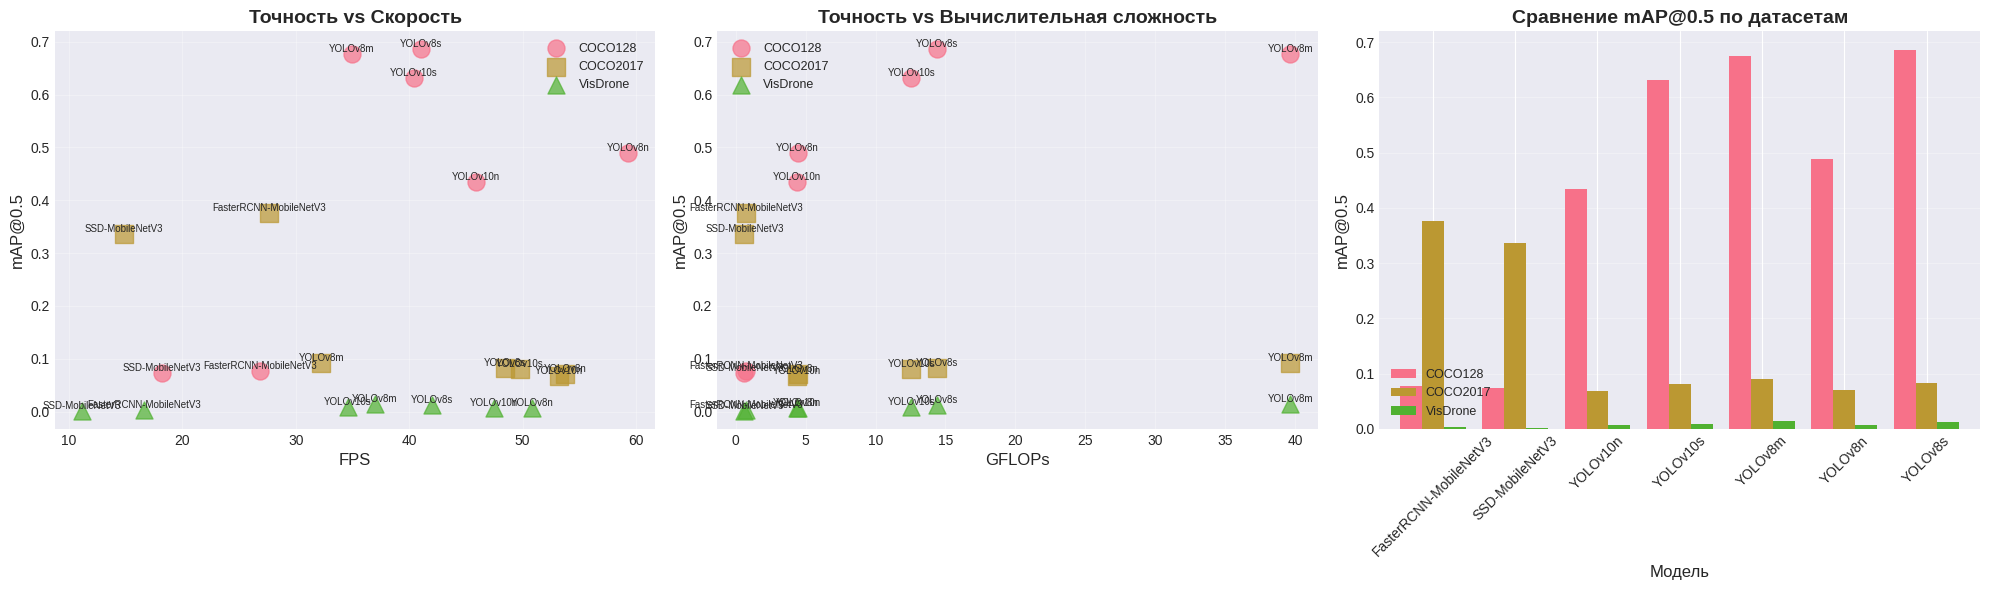

Графики сохранены: /content/drive/MyDrive/benchmark_project/results/benchmark_analysis.png

[OK] Ячейка 10 завершена


In [ ]:

# Строит три графика:
#   1. mAP50 vs FPS (точность против скорости)
#   2. mAP50 vs GFLOPs (точность против сложности)
#   3. Сравнение mAP50 по датасетам (bar chart)

master_csv = os.path.join(RESULTS_DIR, "master_benchmark_results.csv")

if os.path.exists(master_csv):
    df = pd.read_csv(master_csv)

    if len(df) == 0:
        print("[WARN] Нет данных для графиков")
    else:
        # Настройка стиля
        try:
            plt.style.use('seaborn-v0_8-darkgrid')
        except Exception:
            try:
                plt.style.use('seaborn-darkgrid')
            except Exception:
                plt.style.use('ggplot')

        sns.set_palette("husl")

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # Уникальные датасеты и маркеры
        datasets_list = df['dataset'].unique()
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

        # График 1: mAP50 vs FPS
        ax1 = axes[0]
        for i, ds in enumerate(datasets_list):
            subset = df[df['dataset'] == ds]
            ax1.scatter(subset['fps'], subset['mAP50'],
                        label=ds, s=150, alpha=0.7,
                        marker=markers[i % len(markers)])
            for _, row in subset.iterrows():
                ax1.annotate(row['model'],
                             (row['fps'], row['mAP50']),
                             fontsize=7, ha='center', va='bottom')
        ax1.set_xlabel('FPS', fontsize=12)
        ax1.set_ylabel('mAP@0.5', fontsize=12)
        ax1.set_title('Точность vs Скорость', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)

        # График 2: mAP50 vs GFLOPs
        ax2 = axes[1]
        for i, ds in enumerate(datasets_list):
            subset = df[df['dataset'] == ds].dropna(subset=['gflops'])
            if len(subset) > 0:
                ax2.scatter(subset['gflops'], subset['mAP50'],
                            label=ds, s=150, alpha=0.7,
                            marker=markers[i % len(markers)])
                for _, row in subset.iterrows():
                    ax2.annotate(row['model'],
                                 (row['gflops'], row['mAP50']),
                                 fontsize=7, ha='center', va='bottom')
        ax2.set_xlabel('GFLOPs', fontsize=12)
        ax2.set_ylabel('mAP@0.5', fontsize=12)
        ax2.set_title('Точность vs Вычислительная сложность', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)

        # График 3: Сравнение mAP50 по датасетам (bar chart)
        ax3 = axes[2]
        pivot = df.pivot(index='model', columns='dataset', values='mAP50')
        # Оставляем только те датасеты, что есть в данных
        present_datasets = [d for d in datasets_list if d in pivot.columns]
        if present_datasets:
            pivot[present_datasets].plot(kind='bar', ax=ax3, width=0.8)
            ax3.set_xlabel('Модель', fontsize=12)
            ax3.set_ylabel('mAP@0.5', fontsize=12)
            ax3.set_title('Сравнение mAP@0.5 по датасетам', fontsize=14, fontweight='bold')
            ax3.legend(fontsize=9, loc='lower left')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        graph_path = os.path.join(RESULTS_DIR, "benchmark_analysis.png")
        plt.savefig(graph_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Графики сохранены: {graph_path}")

else:
    print("[INFO] master_benchmark_results.csv не найден. Запустите Ячейку 9.")

print("\n[OK] Ячейка 10 завершена")


In [ ]:

# Формирует пакет файлов для передачи аналитику:
#   - CSV с результатами
#   - PNG с графиками
#   - README.md с описанием метрик и условий тестирования

export_dir = os.path.join(RESULTS_DIR, "for_analyst")
os.makedirs(export_dir, exist_ok=True)

# Копирование CSV с результатами
master_csv = os.path.join(RESULTS_DIR, "master_benchmark_results.csv")
if os.path.exists(master_csv):
    shutil.copy(master_csv, os.path.join(export_dir, "full_results.csv"))
    print(f"[OK] full_results.csv")

# Копирование графиков
graph_files = ['benchmark_analysis.png']
for fname in graph_files:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        shutil.copy(fpath, os.path.join(export_dir, fname))
        print(f"[OK] {fname}")

# Создание README.md с описанием
with open(os.path.join(export_dir, "README.md"), 'w', encoding='utf-8') as f:
    f.write("# Результаты бенчмаркинга легковесных детекторов\n\n")
    f.write(f"**Дата:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write(f"**Устройство:** {GPU_NAME}\n\n")
    if GPU_MEM_GB > 0:
        f.write(f"**Память GPU:** {GPU_MEM_GB:.1f} GB\n\n")

    f.write("## Протестированные датасеты\n\n")
    f.write("| Датасет | Изображений | Описание |\n")
    f.write("|---------|------------|----------|\n")
    for ds_name in active_datasets if 'active_datasets' in dir() else ACTIVE_DATASETS:
        if ds_name in DATASETS_CONFIG:
            cfg = DATASETS_CONFIG[ds_name]
            n_img = len(get_image_paths(cfg['images']))
            f.write(f"| {ds_name} | {n_img} | {cfg['description']} |\n")

    f.write("\n## Протестированные модели\n\n")
    f.write("| Модель | Вход | Тип |\n")
    f.write("|--------|------|-----|\n")
    for model_name, loader_name, variant, input_size, needs_shift in MODELS_TO_BENCHMARK:
        model_type = 'YOLO-based' if loader_name in ['yolov8', 'yolov10', 'rtdetr'] else 'Torchvision'
        f.write(f"| {model_name} | {input_size[0]}x{input_size[1]} | {model_type} |\n")

    f.write("\n## Описание метрик\n\n")
    f.write("- **mAP50** — Mean Average Precision при IoU=0.5 (основная метрика точности)\n")
    f.write("- **mAP** — mAP, усредненный по IoU от 0.5 до 0.95 с шагом 0.05\n")
    f.write("- **mAP75** — mAP при строгом IoU=0.75\n")
    f.write("- **FPS** — количество кадров в секунду\n")
    f.write("- **avg_latency_ms** — средняя задержка инференса (мс)\n")
    f.write("- **p95_latency_ms** — 95-й перцентиль задержки (мс)\n")
    f.write("- **GFLOPs** — миллиардов операций с плавающей точкой\n")
    f.write("- **params_millions** — количество параметров (миллионы)\n")
    f.write("- **gpu_peak_memory_mb** — пиковое потребление GPU-памяти (МБ)\n")
    f.write("- **disk_size_mb** — размер файла модели на диске (МБ)\n")

    f.write("\n## Примечания\n\n")
    f.write("- Все YOLO-модели (YOLOv8/v10, RT-DETR) тестировались на входе 640x640\n")
    f.write("- Faster R-CNN и SSD тестировались на входе 320x320 (родной размер)\n")
    f.write("- Torchvision-модели возвращают классы COCO 1..90, применена коррекция (вычитание 1)\n")
    f.write("- Для подсчета mAP использовался pycocotools (COCOeval)\n")
    f.write("- Инференс выполнялся в режиме eval, без дополнительного обучения\n")
    f.write("- Измерение скорости включает прогрев GPU (warmup=10)\n")

print(f"\nЭкспорт готов: {export_dir}")
print("Файлы для передачи Участнику 3:")
for f in sorted(os.listdir(export_dir)):
    fpath = os.path.join(export_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

print("\n" + "=" * 70)

print("=" * 70)

[OK] full_results.csv
[OK] benchmark_analysis.png

Экспорт готов: /content/drive/MyDrive/benchmark_project/results/for_analyst
Файлы для передачи Участнику 3:
  README.md (2.4 KB)
  benchmark_analysis.png (173.9 KB)
  full_results.csv (4.8 KB)

НОУТБУК УЧАСТНИКА 2 ЗАВЕРШЕН
Данные готовы для анализа Участником 3
